#  Sector Clustering Analysis

In [1]:
import sys
import os

sys.path.append(os.path.abspath(".."))

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA

from analytics.db import run_query

fact_analysis = run_query("""
SELECT *
FROM fact_analysis
""")

fact_profit_loss = run_query("""
SELECT *
FROM fact_profit_loss
""")

fact_balance_sheet = run_query("""
SELECT *
FROM fact_balance_sheet
""")

def extract_percentage(value):

    if pd.isnull(value):
        return None

    try:
        return float(
            str(value)
            .split(":")[-1]
            .replace("%", "")
            .strip()
        )

    except:
        return None

# Feature engineering

In [2]:
fact_analysis["sales_growth_pct"] = fact_analysis[
    "compounded_sales_growth"
].apply(extract_percentage)

fact_analysis["profit_growth_pct"] = fact_analysis[
    "compounded_profit_growth"
].apply(extract_percentage)

fact_analysis["roe_pct"] = fact_analysis[
    "roe"
].apply(extract_percentage)

fact_analysis["stock_cagr_pct"] = fact_analysis[
    "stock_price_cagr"
].apply(extract_percentage)

# Latest Records

In [3]:
latest_profit = fact_profit_loss.sort_values(
    "sorting_order",
    ascending=False
).groupby("company_id").first().reset_index()

latest_balance = fact_balance_sheet.sort_values(
    "sorting_order",
    ascending=False
).groupby("company_id").first().reset_index()

latest_analysis = fact_analysis.groupby(
    "company_id"
).first().reset_index()

# Clustering Data Sets


In [4]:
cluster_df = latest_profit.merge(
    latest_balance,
    on="company_id",
    how="left"
)

cluster_df = cluster_df.merge(
    latest_analysis[
        [
            "company_id",
            "sales_growth_pct",
            "profit_growth_pct",
            "roe_pct",
            "stock_cagr_pct"
        ]
    ],
    on="company_id",
    how="left"
)

In [6]:
cluster_features = cluster_df[
    [
        "opm_percentage",
        "roe_pct",
        "sales_growth_pct",
        "profit_growth_pct",
        "debt_to_equity",
        "net_profit_margin_pct"
    ]
].fillna(0)

scaler = StandardScaler()

scaled_features = scaler.fit_transform(
    cluster_features
)

In [7]:
inertia = []

k_values = range(1, 10)

for k in k_values:

    kmeans = KMeans(
        n_clusters=k,
        random_state=42
    )

    kmeans.fit(scaled_features)

    inertia.append(kmeans.inertia_)

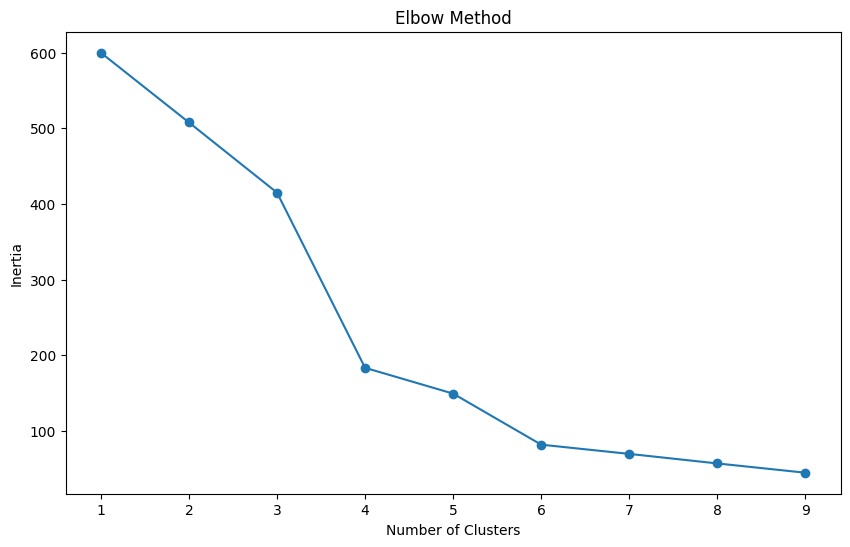

In [8]:
plt.figure(figsize=(10,6))

plt.plot(
    k_values,
    inertia,
    marker="o"
)

plt.title("Elbow Method")

plt.xlabel("Number of Clusters")

plt.ylabel("Inertia")

plt.show()

In [9]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42
)

cluster_df["cluster"] = kmeans.fit_predict(
    scaled_features
)

In [10]:
pca = PCA(n_components=2)

pca_components = pca.fit_transform(
    scaled_features
)

cluster_df["pca1"] = pca_components[:,0]
cluster_df["pca2"] = pca_components[:,1]

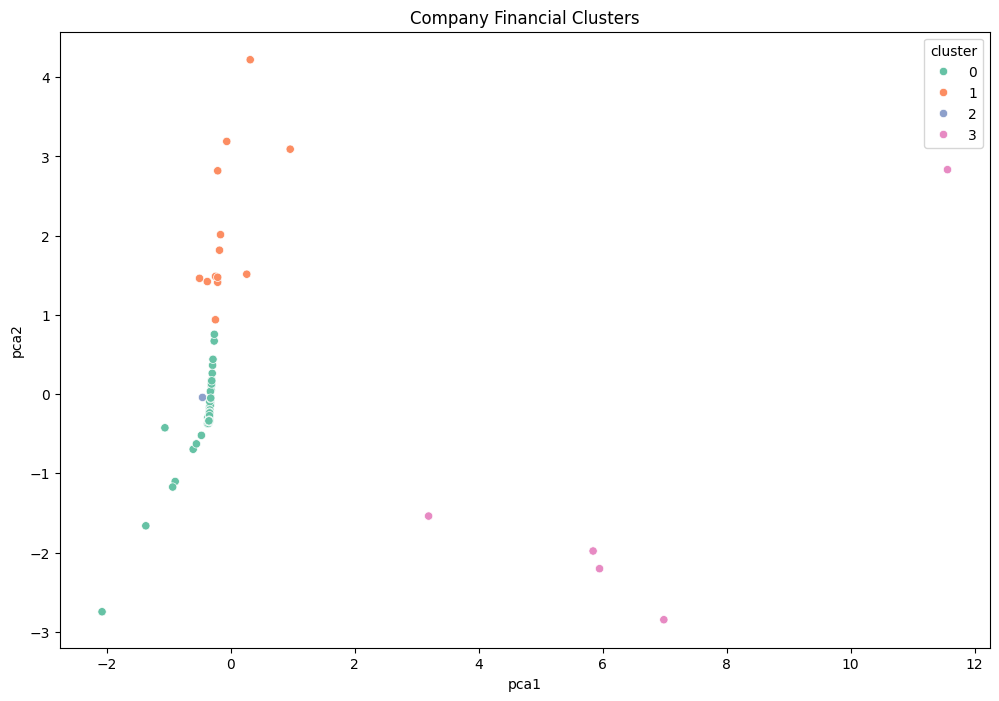

In [11]:
plt.figure(figsize=(12,8))

sns.scatterplot(
    data=cluster_df,
    x="pca1",
    y="pca2",
    hue="cluster",
    palette="Set2"
)

plt.title("Company Financial Clusters")

plt.show()

In [12]:
dbscan = DBSCAN(
    eps=1.5,
    min_samples=5
)

cluster_df["dbscan_cluster"] = dbscan.fit_predict(
    scaled_features
)

In [13]:
cluster_df["cluster"].value_counts()

cluster
0    81
1    13
3     5
2     1
Name: count, dtype: int64

In [14]:
cluster_df["dbscan_cluster"].value_counts()

dbscan_cluster
 0    90
-1    10
Name: count, dtype: int64

In [ ]:
cluster_df.to_csv(
    "../exports/company_clusters.csv",
    index=False
)